# Capstone A — E-commerce EDA & Insight Report

**Goal:** turn one year of raw, messy orders into a decision a stakeholder can act on.

We follow the workflow from Lesson 1.1: **load -> clean -> explore -> visualize -> insight**. Every number here is computed live from `../data/ecommerce_orders.csv`. Run all cells top to bottom.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'figure.figsize':(9,4),'axes.grid':True,'grid.color':'#eee',
                     'axes.axisbelow':True,'axes.spines.top':False,'axes.spines.right':False})
raw = pd.read_csv('../data/ecommerce_orders.csv')
print('rows, cols:', raw.shape)
raw.head()

rows, cols: (5015, 11)


,order_id,order_date,customer_id,region,category,channel,quantity,unit_price,discount,order_value,is_returned
0,104015,2025-09-21,11126,West,Sports,Web,2,39.60,0.00,79.20,False
1,103527,2025-12-06,10002,East,Electronics,Mobile,1,137.39,0.10,123.65,False
2,101420,2025-12-07,12771,West,Apparel,Web,2,68.93,0.00,137.86,False
3,101352,2025-09-02,12522,West,Home,Web,1,29.09,0.05,27.64,False
4,103125,2025-12-02,10534,North,Beauty,Mobile,1,29.18,0.20,23.34,False


## 1. Inspect — what did we get?
First questions on any new dataset: how big, what types, and where are the holes?

In [2]:
raw.info()
print('\nMissing values per column:')
print(raw.isna().sum())
print('\nDuplicate rows:', raw.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     5015 non-null   int64  
 1   order_date   5015 non-null   object 
 2   customer_id  5015 non-null   int64  
 3   region       4864 non-null   object 
 4   category     5015 non-null   object 
 5   channel      5015 non-null   object 
 6   quantity     5015 non-null   int64  
 7   unit_price   5015 non-null   float64
 8   discount     5015 non-null   float64
 9   order_value  5015 non-null   float64
 10  is_returned  5015 non-null   bool   
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 396.8+ KB

Missing values per column:
order_id         0
order_date       0
customer_id      0
region         151
category         0
channel          0
quantity         0
unit_price       0
discount         0
order_value      0
is_returned      0
dtype: int64

Duplicate rows: 15


## 2. Clean — make it trustworthy
- drop duplicate rows
- parse the string dates into real dates
- remove impossible `order_value` entries (<= 0 or an absurd 99999 outlier)
- label missing `region` as 'Unknown' rather than silently dropping rows

In [3]:
df = raw.drop_duplicates().copy()
df['order_date'] = pd.to_datetime(df['order_date'])
bad = (df['order_value'] <= 0) | (df['order_value'] >= 10000)
print('removing', int(bad.sum()), 'bad order_value rows')
df = df[~bad].copy()
df['region'] = df['region'].fillna('Unknown')
df['month'] = df['order_date'].dt.month
print('clean rows:', len(df))

removing 8 bad order_value rows
clean rows: 4992


## 3. Explore — the headline numbers
Note we report the **median** order value alongside the mean, because order value is right-skewed (Lesson 1.3).

In [4]:
gross = df['order_value'].sum()
print(f'Gross revenue : ${gross:,.0f}')
print(f'Avg order val : ${df.order_value.mean():.2f}  (median ${df.order_value.median():.2f})')
bym = df.groupby('month')['order_value'].sum()
print(f'Q4 share      : {bym.loc[[10,11,12]].sum()/gross:.1%}')
by_cat = df.groupby('category')['order_value'].sum().sort_values(ascending=False)
print('\nRevenue by category:'); print((by_cat/1000).round(1).astype(str) + ' k')

Gross revenue : $802,017
Avg order val : $160.66  (median $94.08)
Q4 share      : 38.5%

Revenue by category:
category
Electronics    398.6 k
Apparel        125.5 k
Home           118.5 k
Sports         112.8 k
Beauty          46.7 k
Name: order_value, dtype: object


## 4. Visualize
### Monthly revenue — a strong Q4

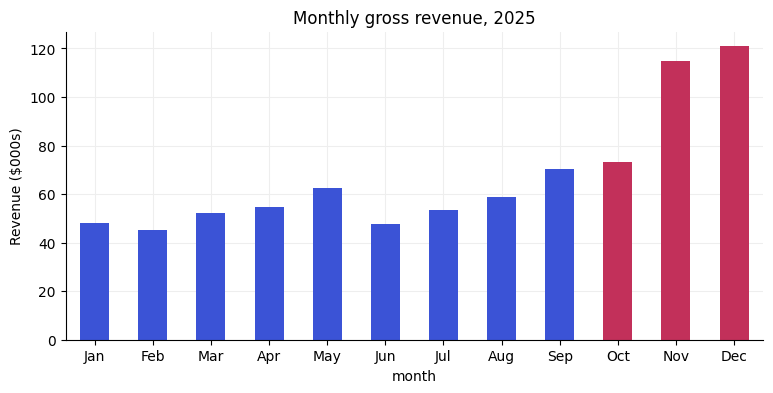

In [5]:
colors = ['#c2305a' if m in (10,11,12) else '#3b53d6' for m in bym.index]
ax = (bym/1000).plot.bar(color=colors)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
ax.set_ylabel('Revenue ($000s)'); ax.set_title('Monthly gross revenue, 2025'); plt.show()

### Order value distribution — right-skewed

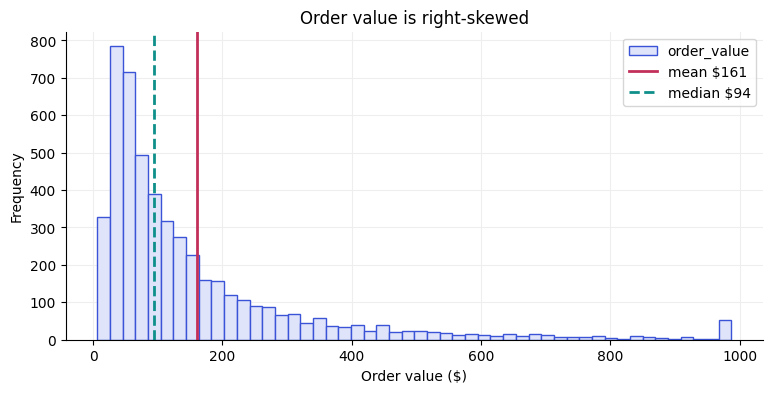

In [6]:
ax = df['order_value'].clip(upper=df.order_value.quantile(.99)).plot.hist(bins=50, color='#dfe4fb', edgecolor='#3b53d6')
ax.axvline(df.order_value.mean(), color='#c2305a', lw=2, label=f'mean ${df.order_value.mean():.0f}')
ax.axvline(df.order_value.median(), color='#0e8f8a', lw=2, ls='--', label=f'median ${df.order_value.median():.0f}')
ax.set_xlabel('Order value ($)'); ax.legend(); ax.set_title('Order value is right-skewed'); plt.show()

### Returns — where net revenue leaks

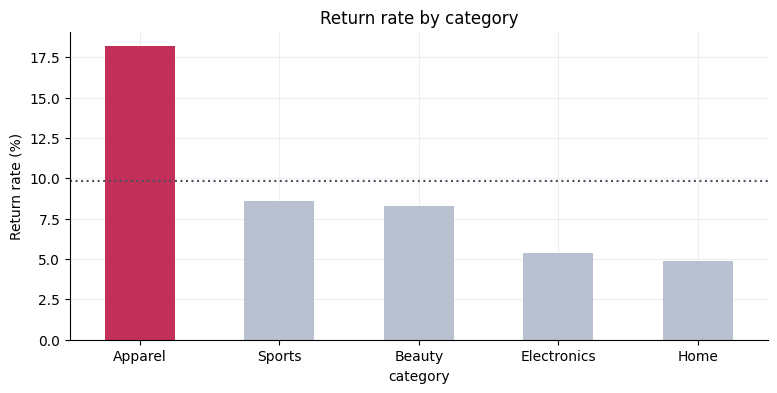

Revenue lost to returns: $65,418


In [7]:
ret = df.groupby('category')['is_returned'].mean().sort_values(ascending=False)
ax = (ret*100).plot.bar(color=['#c2305a' if c==ret.index[0] else '#b9c0d0' for c in ret.index])
ax.axhline(df.is_returned.mean()*100, color='#4a5160', ls=':'); ax.set_xticklabels(ret.index, rotation=0)
ax.set_ylabel('Return rate (%)'); ax.set_title('Return rate by category'); plt.show()
df['net_value'] = np.where(df['is_returned'], 0.0, df['order_value'])
loss = df.order_value.sum() - df.net_value.sum()
print(f'Revenue lost to returns: ${loss:,.0f}')

## 5. Insight & recommendation

**What the data says**

1. **Revenue is highly seasonal** — Q4 (Oct-Dec) drives ~38% of annual revenue, peaking in December. Inventory, staffing, and ad budget should be weighted toward the holiday quarter.
2. **Electronics is the revenue engine** (~50% of gross) but **Apparel is the margin leak**: its ~18% return rate (vs ~10% overall) quietly erases tens of thousands in net revenue.
3. **Order value is right-skewed**, so the **median (~$94)** describes the typical order better than the mean (~$161); use the median when setting free-shipping thresholds.

**Recommendation:** protect Q4 supply for Electronics, and launch a targeted effort to cut Apparel returns (better sizing guides, photography, fit reviews). Even a 3-4 point drop in Apparel returns recovers more net revenue than a comparable lift in a low-return category.

*Next:* a controlled A/B test of a sizing-guide change (see Track 5) would quantify the return-rate impact causally.